# Helmet Detection Model

Goal: detect whether a motorcycle rider is wearing a helmet, using the Kaggle dataset `vishalkirthikk/helmet-detection-dataset-helmet-vs-no-helmet`.

We'll build this step by step, in this order:
1. **Download & explore the dataset** (this notebook, right now) — figure out what's actually inside it before writing any model code.
2. Load & preprocess images (resizing, normalization, train/val/test split).
3. Build a CNN (understand what each layer does).
4. Train it and watch loss/accuracy curves.
5. Evaluate properly (confusion matrix, precision/recall — accuracy alone can lie to you on imbalanced data).
6. Run inference on a new image.

Run this in **Google Colab** with a GPU runtime: `Runtime > Change runtime type > GPU`.

## Step 1: Download the dataset

`kagglehub` isn't preinstalled in Colab, so we install it first. It downloads the dataset to a local cache and gives us back the folder path.

In [2]:
!pip install -q kagglehub

import kagglehub

path = kagglehub.dataset_download("vishalkirthikk/helmet-detection-dataset-helmet-vs-no-helmet")
print("Path to dataset files:", path)

100%|██████████| 2.35G/2.35G [00:19<00:00, 127MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vishalkirthikk/helmet-detection-dataset-helmet-vs-no-helmet/versions/1


## Step 2: Explore the folder structure

Before touching any modeling code, we need to answer some basic questions:
- Is this a **classification** dataset (two folders: `helmet/` and `no_helmet/`, one label per image) or an **object detection** dataset (images + annotation files with bounding boxes, e.g. XML/YOLO `.txt` files)?
- How many images per class? (If it's very imbalanced, e.g. 90% helmet / 10% no-helmet, that changes how we train and evaluate.)
- What format/size are the images?

The cell below walks the downloaded folder and prints its structure plus file counts per subfolder.

In [3]:
import os

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")
    # only show a few example filenames per folder, not thousands of lines
    for f in files[:3]:
        print(f"{indent}  - {f}")
    if len(files) > 3:
        print(f"{indent}  ... and {len(files) - 3} more")

1/  (0 files)
  helmet/  (0 files)
    helmet/  (554 files)
      - 20240930_121538.jpg
      - images-215.jpeg
      - images-53.jpeg
      ... and 551 more
  no_helmet/  (0 files)
    no_helmet/  (715 files)
      - 419.jpg
      - 648.jpg
      - 207.jpg
      ... and 712 more


## Step 3: Look at some actual images

Folder names and counts only tell us so much — let's actually look at a few sample images from each class folder to sanity-check labels and image quality (blurry? cropped to just the head? full-body photos?).

**Edit `class_dirs` below** once you've seen the folder structure printed above, so it points at the real class folders.

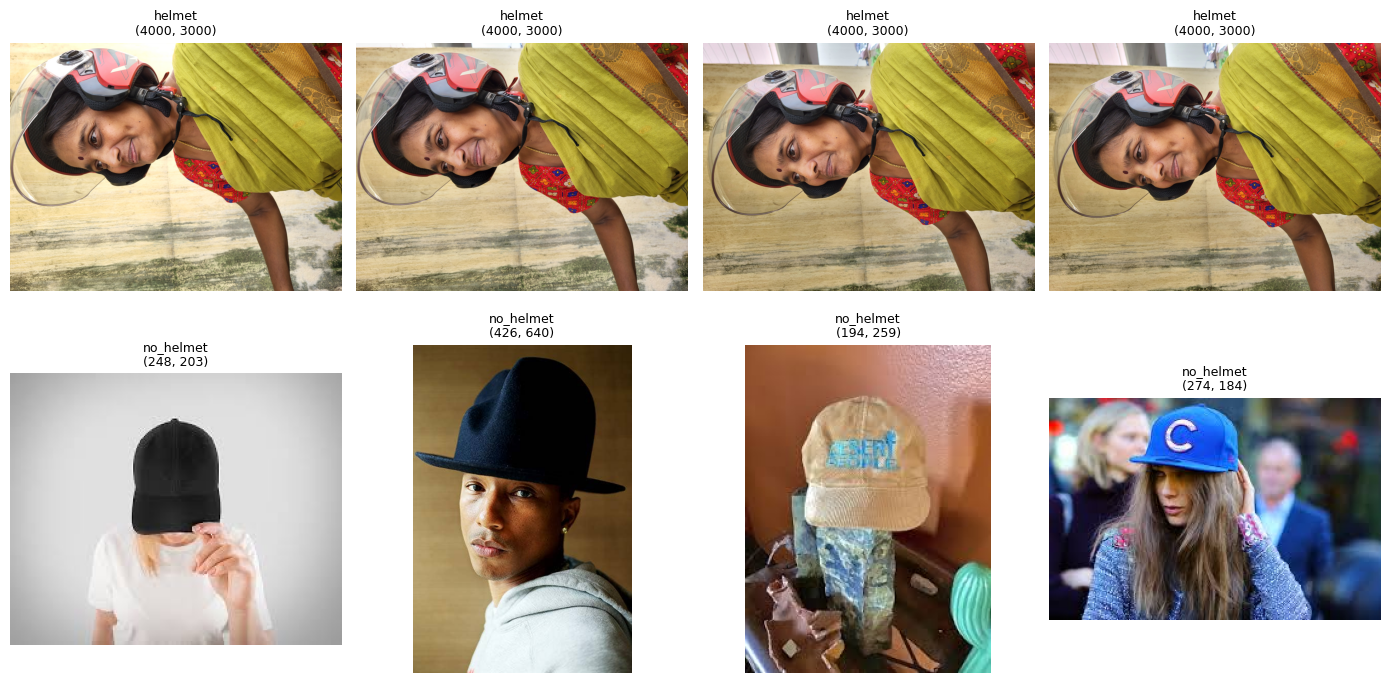

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import glob

# TODO: update these to match the real subfolder names from Step 2's output
class_dirs = {
    "helmet": os.path.join(path, "helmet", "helmet"),
    "no_helmet": os.path.join(path, "no_helmet", "no_helmet"),
}

fig, axes = plt.subplots(len(class_dirs), 4, figsize=(14, 3.5 * len(class_dirs)))
for row, (label, d) in enumerate(class_dirs.items()):
    files = sorted(glob.glob(os.path.join(d, "*")))[:4]
    for col in range(4):
        ax = axes[row, col] if len(class_dirs) > 1 else axes[col]
        if col < len(files):
            img = Image.open(files[col])
            ax.imshow(img)
            ax.set_title(f"{label}\n{img.size}", fontsize=9)
        ax.axis("off")
plt.tight_layout()
plt.show()

## Step 4: Build a stratified train/val/test split

We split the file paths (not the images themselves yet) into three sets:
- **Train (70%)** — what the model learns from.
- **Validation (15%)** — used during training to check for overfitting and tune things like when to stop.
- **Test (15%)** — touched only once, at the very end, for an honest final evaluation.

We use `stratify=labels` so each split keeps the same class ratio (~554 helmet : 715 no_helmet) instead of, say, the test set randomly ending up 90% one class.

In [5]:
from sklearn.model_selection import train_test_split
import numpy as np

IMAGE_EXTENSIONS = ("*.jpg", "*.jpeg", "*.png")

def list_images(d):
    files = []
    for ext in IMAGE_EXTENSIONS:
        files.extend(glob.glob(os.path.join(d, ext)))
    return files

helmet_files = list_images(class_dirs["helmet"])
no_helmet_files = list_images(class_dirs["no_helmet"])

all_files = np.array(helmet_files + no_helmet_files)
# label 1 = helmet, 0 = no_helmet
all_labels = np.array([1] * len(helmet_files) + [0] * len(no_helmet_files))

print(f"Total images: {len(all_files)}  (helmet={len(helmet_files)}, no_helmet={len(no_helmet_files)})")

# First split off the test set (15%)
train_val_files, test_files, train_val_labels, test_labels = train_test_split(
    all_files, all_labels, test_size=0.15, stratify=all_labels, random_state=42
)

# Then split the remainder into train (~70% of total) and val (~15% of total)
train_files, val_files, train_labels, val_labels = train_test_split(
    train_val_files, train_val_labels, test_size=0.15 / 0.85, stratify=train_val_labels, random_state=42
)

print(f"Train: {len(train_files)}  Val: {len(val_files)}  Test: {len(test_files)}")
print(f"Train class balance: helmet={train_labels.sum()}, no_helmet={len(train_labels) - train_labels.sum()}")

Total images: 1177  (helmet=472, no_helmet=705)
Train: 823  Val: 177  Test: 177
Train class balance: helmet=330, no_helmet=493


## Step 5: Build a `tf.data` pipeline

Instead of loading 1,269 images into RAM up front, we build a pipeline that, for each file path:
1. Reads the raw file bytes (`tf.io.read_file`)
2. Decodes it into a pixel array (`tf.io.decode_image`)
3. Resizes it to a fixed size — models need every input to be the same shape. We pick **160x160**, a good speed/accuracy tradeoff for a small CNN on a laptop GPU.
4. Rescales pixel values from `[0, 255]` to `[0, 1]` — neural nets train more stably on small, centered input ranges than on raw 0-255 integers.

Then we batch (process 32 images at a time) and `prefetch` (prepare the next batch on CPU while the GPU is busy training on the current one, so the GPU is never idle waiting for data).

In [8]:
import tensorflow as tf

IMG_SIZE = (160, 160)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)  # handles jpg/jpeg/png
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0  # scale pixels to [0, 1]
    return img, label

def make_dataset(files, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(files), seed=42)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_files, train_labels, shuffle=True)
val_ds = make_dataset(val_files, val_labels)
test_ds = make_dataset(test_files, test_labels)

# quick sanity check on shapes
for images, labels in train_ds.take(1):
    print("batch images shape:", images.shape)
    print("batch labels shape:", labels.shape)

ModuleNotFoundError: No module named 'tensorflow'

## Step 6: Sanity-check a batch visually

Numbers and shapes can look right while the actual content is wrong (e.g. mismatched labels). Let's plot a batch with its labels to confirm everything lines up.

In [ ]:
class_names = {0: "no_helmet", 1: "helmet"}

images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(class_names[int(labels[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Step 7: Data augmentation

With only ~888 training images, the model can latch onto irrelevant details (a specific background, a particular lighting condition) instead of the actual concept of "helmet." Data augmentation randomly perturbs each image a little differently on every training epoch — flipping, rotating slightly, zooming, adjusting contrast — so the model sees many variations and is forced to learn features that survive those changes.

Important detail: these are **Keras layers**, and they only apply during training (`model.fit`). During evaluation/inference the layers pass images through unchanged. That's why we can put them directly inside the model rather than in the `tf.data` pipeline.

Let's visualize what augmentation actually does to one image first, so it's not an abstract idea.

In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),      # a helmet is still a helmet mirrored
    layers.RandomRotation(0.08),          # small tilt, like a camera not perfectly level
    layers.RandomZoom(0.1),               # rider slightly closer/farther from camera
    layers.RandomContrast(0.1),           # different lighting conditions
], name="data_augmentation")

# visualize: same image, 9 different random augmentations
sample_image = images[0:1]  # from the batch we pulled in Step 6, shape (1, 160, 160, 3)

plt.figure(figsize=(10, 10))
for i in range(9):
    augmented = data_augmentation(sample_image, training=True)
    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented[0].numpy())
    plt.axis("off")
plt.suptitle("Same image, 9 random augmentations")
plt.tight_layout()
plt.show()

## Step 8: Build the CNN

What each layer type does to the image:

- **`Conv2D(filters, 3)`** — slides a small 3x3 window across the image, learning a filter that responds to a specific local pattern (an edge, a curve, a color transition). `filters` is *how many different patterns* that layer learns to detect at once. Early layers learn simple things (edges, gradients); because each layer stacks on the previous one's output, deeper layers combine those into more complex shapes (curves → helmet-dome shapes, head-and-shoulders silhouettes).
- **`BatchNormalization`** — rescales activations between layers so training doesn't get destabilized by values drifting to very large/small ranges as the signal passes through many layers. Mostly a training-stability tool, not something that changes what the model can represent.
- **`MaxPooling2D(2)`** — takes the max value in every 2x2 block, halving the image's height and width. This does two things: (1) reduces computation as we go deeper, (2) adds a bit of translation tolerance — a helmet detected 2 pixels to the left still triggers the same feature.
- **`GlobalAveragePooling2D`** — instead of flattening the final feature maps into one giant vector (which creates a huge, overfitting-prone Dense layer), this averages each feature map down to a single number. Far fewer parameters, which matters a lot given we only have ~888 training images.
- **`Dropout(0.5)`** — during training, randomly zeroes out 50% of the neurons on each pass. This prevents neurons from co-adapting/relying on each other for one specific memorized pattern, which is another anti-overfitting measure.
- **Final `Dense(1, activation='sigmoid')`** — outputs a single number between 0 and 1: the model's estimated probability the image shows a helmet. Sigmoid + one unit is the standard setup for binary classification (as opposed to `softmax` with 2 units, which is for 3+ classes).

Filter counts increase with depth (32 → 64 → 128) because early layers only need a few patterns (edges, colors) while deeper layers need many more combinations to represent complex shapes.

In [ ]:
from tensorflow.keras import Sequential, Input

model = Sequential([
    Input(shape=(160, 160, 3)),
    data_augmentation,

    # Block 1: learn simple patterns (edges, color transitions)
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),

    # Block 2: combine into slightly more complex textures/shapes
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),

    # Block 3: more complex shapes (curves, dome-like forms)
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),

    # Block 4: high-level combinations (head+helmet silhouette parts)
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),

    # Classification head
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
], name="helmet_cnn")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")],
)

model.summary()

Model: "helmet_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 20, 20, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,881 (1011.25 KB)

 Trainable params: 258,177 (1008.50 KB)

 Non-trainable params: 704 (2.75 KB)

## Step 9: Train the model

A few things we set up here, and why:

- **`class_weight`** — remember the mild imbalance (554 helmet vs 715 no_helmet)? We tell Keras to weight mistakes on the minority class (helmet) more heavily during training, so the model doesn't get a free ride by leaning toward predicting the majority class.
- **`EarlyStopping`** — we watch `val_loss` (loss on the validation set, which the model never trains on). If it stops improving for `patience` epochs in a row, training halts and we automatically roll back to the best-performing weights (`restore_best_weights=True`). This is our main defense against overfitting: past a certain point, a model keeps improving on training data while actually getting *worse* on unseen data — early stopping catches that moment instead of us guessing an epoch count upfront.
- **`ModelCheckpoint`** — saves the best model to disk as we go, in case the Colab runtime disconnects mid-training.

We set `epochs=30` as an upper bound — early stopping will likely cut training short before that.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight("balanced", classes=np.unique(train_labels), y=train_labels)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_helmet_model.keras", monitor="val_loss", save_best_only=True),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=callbacks,
)

NameError: name 'np' is not defined

## Step 10: Plot the training curves

What to look for:
- **Loss curves converging together** (train and val both decreasing, staying close) = healthy learning.
- **Train loss keeps dropping while val loss flattens or rises** = overfitting — the model is memorizing training data rather than generalizing. If you see this despite augmentation/dropout/early stopping, the next lever would be simplifying the model or getting more data.
- **Both curves flat/high from the start** = underfitting — the model isn't learning much at all (could mean learning rate is wrong, or the model is too small/large for the task).

In [ ]:
hist = history.history
epochs_range = range(1, len(hist["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, hist["loss"], label="train loss")
axes[0].plot(epochs_range, hist["val_loss"], label="val loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(epochs_range, hist["accuracy"], label="train accuracy")
axes[1].plot(epochs_range, hist["val_accuracy"], label="val accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 11: Evaluate on the test set

This is the first and only time we touch the test set — it was never used for training or for early-stopping decisions, so the numbers here are an honest estimate of real-world performance.

We look at more than accuracy:
- **Confusion matrix** — a 2x2 grid of (true class) x (predicted class) counts. The two off-diagonal cells are the two ways the model can be wrong, and they're not equally bad here: predicting "helmet" for a rider who isn't wearing one (a **false negative for `no_helmet`**) is the dangerous error for a safety application — a real violation goes undetected. Predicting "no_helmet" for someone wearing one (false positive) is just an annoyance.
- **`classification_report`** — precision/recall/F1 computed *separately for each class*. This is why we need it: the `Recall` Keras tracked during training only measured the "helmet" class (label 1) by default. We specifically want to see `no_helmet`'s recall too.

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# collect true labels and predicted probabilities across the whole test set
y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
y_prob = model.predict(test_ds).flatten()
y_pred = (y_prob >= 0.5).astype(int)

test_loss, test_acc, test_prec, test_rec = model.evaluate(test_ds)
print(f"\nTest loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}")

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=["no_helmet", "helmet"]))

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=["no_helmet", "helmet"], cmap="Blues")
plt.title("Confusion matrix (test set)")
plt.show()

## Step 12: Transfer learning with MobileNetV2

Instead of learning visual features from scratch on ~823 images, we reuse **MobileNetV2** pretrained on ImageNet (1.4M images, 1000 classes). Its early/middle layers already recognize general-purpose visual features — edges, textures, curves, shapes — regardless of the task they were originally trained for. We freeze those layers (`base_model.trainable = False`, so their weights don't change) and only train a small new classifier head that learns to combine those existing features into "helmet vs no_helmet." Far fewer new parameters to learn than a from-scratch CNN, so it's much less prone to overfitting on a small dataset.

Two important details:
- **Different normalization**: MobileNetV2 was trained with pixels scaled to `[-1, 1]`, not the `[0, 1]` scaling we used for our own CNN. So we build a fresh pipeline that skips the manual `/255` step and instead uses `tf.keras.applications.mobilenet_v2.preprocess_input`, which does the correct scaling for this specific model. Mismatching this would silently wreck performance — the pretrained weights expect their original input distribution.
- **`base_model(x, training=False)`**: even though the base model's weights are frozen, we still explicitly pass `training=False` so its `BatchNormalization` layers keep using their pretrained running statistics instead of recalculating them from our small batches.

In [ ]:
# Fresh pipeline WITHOUT the manual /255 step (MobileNetV2 handles its own scaling)
def load_raw(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label  # stays in [0, 255]

def make_raw_dataset(files, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(files), seed=42)
    ds = ds.map(load_raw, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds_tl = make_raw_dataset(train_files, train_labels, shuffle=True)
val_ds_tl = make_raw_dataset(val_files, val_labels)
test_ds_tl = make_raw_dataset(test_files, test_labels)

# Build the model
base_model = tf.keras.applications.MobileNetV2(input_shape=(160, 160, 3), include_top=False, weights="imagenet")
base_model.trainable = False

inputs = tf.keras.Input(shape=(160, 160, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

tl_model = tf.keras.Model(inputs, outputs, name="helmet_mobilenetv2")

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")],
)

tl_model.summary()

## Step 13: Train the transfer-learning model

Same `class_weight` + `EarlyStopping` setup as before. Since we're only training a small head (not the whole network), this should converge faster and generalize much better than Step 9's from-scratch training.

In [ ]:
callbacks_tl = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_helmet_mobilenetv2.keras", monitor="val_loss", save_best_only=True),
]

history_tl = tl_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=callbacks_tl,
)

## Step 14: Evaluate the transfer-learning model on the test set

Same evaluation as Step 11, now for `tl_model` on `test_ds_tl` (the raw-pixel pipeline it expects). This is the real comparison point against the from-scratch CNN's test results.

In [ ]:
y_true_tl = np.concatenate([labels.numpy() for _, labels in test_ds_tl])
y_prob_tl = tl_model.predict(test_ds_tl).flatten()
y_pred_tl = (y_prob_tl >= 0.5).astype(int)

test_loss_tl, test_acc_tl, test_prec_tl, test_rec_tl = tl_model.evaluate(test_ds_tl)
print(f"\nTest loss: {test_loss_tl:.4f}  Test accuracy: {test_acc_tl:.4f}")

print("\nClassification report:")
print(classification_report(y_true_tl, y_pred_tl, target_names=["no_helmet", "helmet"]))

ConfusionMatrixDisplay.from_predictions(y_true_tl, y_pred_tl, display_labels=["no_helmet", "helmet"], cmap="Blues")
plt.title("Confusion matrix (test set) - MobileNetV2 transfer learning")
plt.show()

## Step 15: Save the model

Colab runtimes are temporary — everything in memory (including `tl_model`) disappears when the runtime disconnects or times out. Save the model to a file and download it to your own machine so this work doesn't evaporate.

In [ ]:
from google.colab import files

tl_model.save("helmet_detector.keras")
files.download("helmet_detector.keras")  # saves to your computer's Downloads folder

## Step 16: Run inference on a new image

This is the actual point of the project: given a brand-new photo (not from the dataset at all), predict helmet vs no_helmet.

`files.upload()` needs a live JS connection back to Colab's frontend, which can break (browser extensions, cookie settings, reconnected runtimes). To sidestep that entirely, we load a test image **by URL** instead — find any photo online (e.g. right-click an image in a Google Images search → "Copy image address"), paste the URL into `IMAGE_URL` below, and re-run the cell for each new photo you want to test.

Important: we must preprocess the new image **exactly the same way** as training (resize to 160x160, same pixel range) — the model was trained on that specific input distribution and will give nonsense predictions if we feed it something different (e.g. forgetting to resize, or normalizing to `[0,1]` instead of relying on `preprocess_input`).

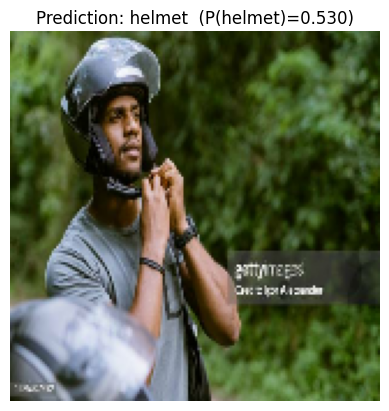

In [ ]:
import urllib.request

IMAGE_URL = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQtSqojVopzWzbMBnAvSV9HUNzebjMQz_tAmCh-d5leYl1Kbj7v-EpBD4w&s=10"  # e.g. https://example.com/photo.jpg
image_path = "test_image.jpg"
urllib.request.urlretrieve(IMAGE_URL, image_path)

# If you'd rather upload from your own computer and the widget is working, use this instead:
# uploaded = files.upload()
# image_path = next(iter(uploaded.keys()))

def predict_helmet(path, model):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.expand_dims(img, axis=0)  # add batch dimension: (160,160,3) -> (1,160,160,3)
    prob = model.predict(img, verbose=0)[0][0]
    label = "helmet" if prob >= 0.5 else "no_helmet"
    return label, float(prob), img[0]

label, prob, display_img = predict_helmet(image_path, tl_model)

plt.imshow(display_img.numpy().astype("uint8"))
plt.title(f"Prediction: {label}  (P(helmet)={prob:.3f})")
plt.axis("off")
plt.show()

## Step 17: How confident is the model, really?

A correct prediction with `P(helmet)=0.52` and one with `P(helmet)=0.97` are not the same thing — the first is barely a guess. Let's look at the *distribution* of confidence on the test set, split into correct vs. incorrect predictions.

What we want to see: correct predictions clustered near 0 or 1 (confident and right), and incorrect predictions being the ones near 0.5 (the model "knew" it was unsure). That's a well-behaved model — it's uncertain exactly when it should be. If confident predictions are *also* frequently wrong, that's a real calibration problem, not just an edge case.

In [ ]:
correct = (y_pred_tl == y_true_tl)

plt.figure(figsize=(10, 5))
plt.hist(y_prob_tl[correct], bins=20, alpha=0.6, label="correct", color="tab:green")
plt.hist(y_prob_tl[~correct], bins=20, alpha=0.6, label="incorrect", color="tab:red")
plt.axvline(0.5, color="black", linestyle="--", label="decision threshold")
plt.xlabel("P(helmet)")
plt.ylabel("count")
plt.title("Prediction confidence: correct vs incorrect (test set)")
plt.legend()
plt.show()

# how many predictions are "uncertain" (close to the 0.5 threshold)?
uncertain_band = (y_prob_tl > 0.35) & (y_prob_tl < 0.65)
print(f"{uncertain_band.sum()} / {len(y_prob_tl)} test predictions fall in the uncertain band (0.35-0.65)")
if uncertain_band.sum() > 0:
    acc_uncertain = (y_pred_tl[uncertain_band] == y_true_tl[uncertain_band]).mean()
    print(f"Accuracy within that band: {acc_uncertain:.2%}")
acc_confident = (y_pred_tl[~uncertain_band] == y_true_tl[~uncertain_band]).mean()
print(f"Accuracy outside that band (confident predictions): {acc_confident:.2%}")

## Step 18: Add an "uncertain" bucket to inference

Since we confirmed the 0.35–0.65 band correlates with much lower accuracy (45% vs 94.6%), we update `predict_helmet` to report `uncertain` for predictions in that range instead of forcing a confident-sounding label it doesn't actually have.

In [ ]:
def predict_helmet(path, model, uncertain_low=0.35, uncertain_high=0.65):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.expand_dims(img, axis=0)
    prob = float(model.predict(img, verbose=0)[0][0])

    if uncertain_low < prob < uncertain_high:
        label = "uncertain - needs review"
    elif prob >= 0.5:
        label = "helmet"
    else:
        label = "no_helmet"

    return label, prob, img[0]

label, prob, display_img = predict_helmet(image_path, tl_model)

plt.imshow(display_img.numpy().astype("uint8"))
plt.title(f"Prediction: {label}  (P(helmet)={prob:.3f})")
plt.axis("off")
plt.show()